In [1]:
#!pip install ddeint

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ddeint import ddeint
from scipy.signal import find_peaks
import warnings
warnings.filterwarnings('ignore')

In [3]:
climate_api_data = pd.read_csv("../../data_files/data/climate_api_data_2016_2024.csv")
cases_data = pd.read_csv("../../data_files/data/sivep_notification_data/treated_malaria_notification_data/cumulative_manaus_cases_2016_2023.csv")

In [4]:
cases_data

,date,active_total,active_symptomatic,active_asymptomatic,new_cases,cumulative_cases,year,month,week,day_of_year,active_per_new_case
0,2016-01-01,3520,3212,308,3,3531,2016,1,53,1,880.000000
1,2016-01-02,3529,3217,312,17,3548,2016,1,53,2,196.055556
2,2016-01-03,3530,3218,312,5,3553,2016,1,53,3,588.333333
3,2016-01-04,3525,3214,311,4,3557,2016,1,1,4,705.000000
4,2016-01-05,3515,3205,310,0,3557,2016,1,1,5,3515.000000
...,...,...,...,...,...,...,...,...,...,...,...
3037,2024-04-25,9,9,0,0,47433,2024,4,17,116,9.000000
3038,2024-04-26,2,2,0,0,47433,2024,4,17,117,2.000000
3039,2024-04-27,0,0,0,0,47433,2024,4,17,118,0.000000
3040,2024-04-28,0,0,0,0,47433,2024,4,17,119,0.000000


In [5]:
# Convert date columns to datetime
climate_api_data['date'] = pd.to_datetime(climate_api_data['date'])
cases_data['date'] = pd.to_datetime(cases_data['date'])

In [6]:
start_date = '2017-01-01'
end_date = '2023-12-31'

climate_api_data = climate_api_data[
    (climate_api_data['date'] >= start_date) & 
    (climate_api_data['date'] <= end_date)
].reset_index(drop=True)

cases_data = cases_data[
    (cases_data['date'] >= start_date) & 
    (cases_data['date'] <= end_date)
].reset_index(drop=True)

In [7]:
T_prime = 25.6  # Temperature threshold for biting rate
B_E = 200
p_ME = 0.5        
p_ML = 0.5        
p_MP = 0.5
tau_E = 1
tau_P = 1
c1 = 0.00554
c2 = -0.06737
D1 = 4.0
b1 = 0.3      
b2 = 0.3     
A = 12.5
B = 15.0
C = -48.78
tau_H = 10     # Human incubation period (days) - increased for P. vivax
DD = 105       # Degree-days for P. vivax sporogony
Tmin = 14.5    # Minimum temperature for parasite development
gamma = 1/180   # Faster recovery (60 days) to allow reinfection waves
R_L = 32.67    # Rainfall threshold for breeding sites (mm)
N = 8558       # Human population
M = 50000  # Base mosquito population

r_H = 0.00005

E_M0 = 5000    # Initial exposed mosquitoes
I_M0 = 10

# Get I_H0 from cases_data at the start date
start_date_obj = pd.to_datetime(start_date)
start_row = cases_data[cases_data['date'] == start_date_obj].iloc[0]
I_H0 = start_row['active_total']

print(f"I_H0 (active cases at {start_date}): {I_H0}")

S_H0 = N - I_H0
S_M0 = M - E_M0 - I_M0

I_H0 (active cases at 2017-01-01): 2273


In [8]:
initial_state = np.array([S_H0, I_H0, 0, S_M0, E_M0, I_M0])

In [9]:
def tau_L(Temp):
    """Larval development duration"""
    denom = c1 * Temp + c2
    if denom <= 0:
        return 100
    return 1 / denom

def p_T(Temp):
    """Daily mosquito survival probability"""
    denom = A * Temp**2 + B * Temp + C
    if denom >= 0:
        return 0.85
    return np.exp(-1 / denom)

def p_LT(Temp):
    """Larval survival probability"""
    exponent = c1 * Temp + c2
    if exponent > 10:
        return 0
    return np.exp(-exponent)

def p_LR(Rain, R_L):
    """Larval survival probability due to rain"""
    if Rain < 0 or Rain > R_L:
        return 0
    return (4 * p_ML / R_L**2) * Rain * (R_L - Rain)

def p_ER(Rain, R_L):
    """Egg survival probability due to rain"""
    if Rain < 0 or Rain > R_L:
        return 0
    return (4 * p_ME / R_L**2) * Rain * (R_L - Rain)

def p_PR(Rain, R_L):
    """Pupal survival probability due to rain"""
    if Rain < 0 or Rain > R_L:
        return 0
    return (4 * p_MP / R_L**2) * Rain * (R_L - Rain)

def tau_M(Temp):
    """Sporogonic cycle duration"""
    if Temp <= Tmin:
        return 50
    return DD / (Temp - Tmin)

def mu(Temp):
    """Mosquito mortality rate"""
    p_T_val = p_T(Temp)
    if p_T_val <= 0:
        return 0.15
    mu_val = -np.log(p_T_val)
    return min(mu_val, 0.3)

def a(Temp):
    """Mosquito biting rate"""
    a_val = max(0, (Temp - T_prime) / D1)
    return min(a_val, 0.8)  # Cap at reasonable maximum

def b_rate(Rain, Temp, R_L):
    """Mosquito recruitment rate"""
    tau_L_curr = tau_L(Temp)
    if tau_L_curr <= 0:
        return 0
    
    numerator = B_E * p_ER(Rain, R_L) * p_LR(Rain, R_L) * p_LT(Temp) * p_PR(Rain, R_L)
    denominator = tau_E + tau_L_curr + tau_P
    if denominator <= 0:
        return 0
    return numerator / denominator

def dde_model(Y, t):
    """
    DDE model for malaria transmission
    Y(t) returns state at time t
    """
    # Get current state
    try:
        S_H, I_H, R_H, S_M, E_M, I_M = Y(t)
    except:
        return np.zeros(6)
    
    # Clamp to prevent negative values
    S_H = max(S_H, 1e-6)
    I_H = max(I_H, 1e-6)
    R_H = max(R_H, 1e-6)
    S_M = max(S_M, 1e-6)
    E_M = max(E_M, 1e-6)
    I_M = max(I_M, 1e-6)
    
    # Get climate data for current time
    day_index = int(t)
    if day_index >= len(climate_api_data):
        day_index = len(climate_api_data) - 1
    if day_index < 0:
        day_index = 0
    
    T_curr = climate_api_data.loc[day_index, 'temp_med']
    R_curr = climate_api_data.loc[day_index, 'precip_med']
    
    # Get month for seasonality
    date_str = climate_api_data.loc[day_index, 'date']
    month = pd.to_datetime(date_str).month
    
    # Calculate current parameters
    a_curr = a(T_curr)
    mu_curr = mu(T_curr)
    tau_M_curr = tau_M(T_curr)
    
    # Climate-driven carrying capacity
    temp_factor = max(0.1, min(1, (T_curr - 15) / 15))
    rain_factor = min(1, max(0, R_curr / 30))
    seasonal_factor = 1.5 if (month >= 11 or month <= 5) else 0.5
    K = M * temp_factor * rain_factor * seasonal_factor
    
    # Mosquito recruitment with density dependence
    b_curr = b_rate(R_curr, T_curr, R_L)
    total_mosquitoes = S_M + E_M + I_M
    if K > 0:
        density_factor = max(0, 1 - total_mosquitoes / K)
    else:
        density_factor = 0
    mosquito_birth = b_curr * density_factor * K
    
    # Get delayed states (human incubation period)
    try:
        S_H_delay, I_H_delay, R_H_delay, S_M_delay, E_M_delay, I_M_delay = Y(t - tau_H)
        # Clamp delayed states
        S_H_delay = max(S_H_delay, 0)
        I_H_delay = max(I_H_delay, 0)
        S_M_delay = max(S_M_delay, 0)
        I_M_delay = max(I_M_delay, 0)
    except:
        # Use current state if delay fails
        S_H_delay, I_H_delay, R_H_delay, S_M_delay, E_M_delay, I_M_delay = S_H, I_H, R_H, S_M, E_M, I_M
    
    # Get delayed states (sporogonic cycle)
    tau_M_safe = min(max(tau_M_curr, 1), 50)  # Cap between 1 and 50 days
    try:
        S_H_delay_M, I_H_delay_M, R_H_delay_M, S_M_delay_M, E_M_delay_M, I_M_delay_M = Y(t - tau_M_safe)
        S_H_delay_M = max(S_H_delay_M, 0)
        I_H_delay_M = max(I_H_delay_M, 0)
        S_M_delay_M = max(S_M_delay_M, 0)
    except:
        S_H_delay_M, I_H_delay_M, R_H_delay_M, S_M_delay_M, E_M_delay_M, I_M_delay_M = S_H, I_H, R_H, S_M, E_M, I_M
    
    # Probability of surviving sporogonic cycle
    l_curr = np.exp(-mu_curr * tau_M_safe)
    
    # HUMAN EQUATIONS
    # New infections
    new_infections_h = a_curr * b2 * (I_M / N) * S_H
    dShdt = r_H * N -new_infections_h
    
    # Delayed infections become symptomatic
    dIhdt = a_curr * b2 * (I_M_delay / N) * S_H_delay - gamma * I_H
    
    dRhdt = gamma * I_H
    
    # MOSQUITO EQUATIONS
    # New mosquito recruitment
    dSmdt = mosquito_birth - a_curr * b1 * (I_H / N) * S_M - mu_curr * S_M
    
    # Exposed mosquitoes (incubating)
    dEmdt = (a_curr * b1 * (I_H / N) * S_M - 
             a_curr * b1 * (I_H_delay_M / N) * S_M_delay_M * l_curr - 
             mu_curr * E_M)
    
    # Infectious mosquitoes
    dImdt = a_curr * b1 * (I_H_delay_M / N) * S_M_delay_M * l_curr - mu_curr * I_M
    
    # Ensure derivatives don't drive populations negative
    dShdt = max(dShdt, -S_H / 10)
    dIhdt = max(dIhdt, -I_H / 10)
    dRhdt = max(dRhdt, -R_H / 10)
    dSmdt = max(dSmdt, -S_M / 10)
    dEmdt = max(dEmdt, -E_M / 10)
    dImdt = max(dImdt, -I_M / 10)
    
    return [dShdt, dIhdt, dRhdt, dSmdt, dEmdt, dImdt]

In [10]:
def history(t):
    """Return initial state for times t <= 0"""
    return initial_state

In [11]:
print("Solving DDE...")

# Time points for evaluation (daily for 7 years)
t_eval = np.linspace(0, 2556, 2557)  # 7 years, daily resolution

# Solve the DDE (no args parameter needed - use closure)
sol = ddeint(dde_model, history, t_eval)

print("Solution completed!")

Solving DDE...
Solution completed!


In [12]:
# Extract results
S_H = sol[:, 0]
I_H = sol[:, 1]
R_H = sol[:, 2]
S_M = sol[:, 3]
E_M = sol[:, 4]
I_M = sol[:, 5]

# Ensure no negative values
I_H = np.maximum(I_H, 0)
S_M = np.maximum(S_M, 0)
E_M = np.maximum(E_M, 0)
I_M = np.maximum(I_M, 0)

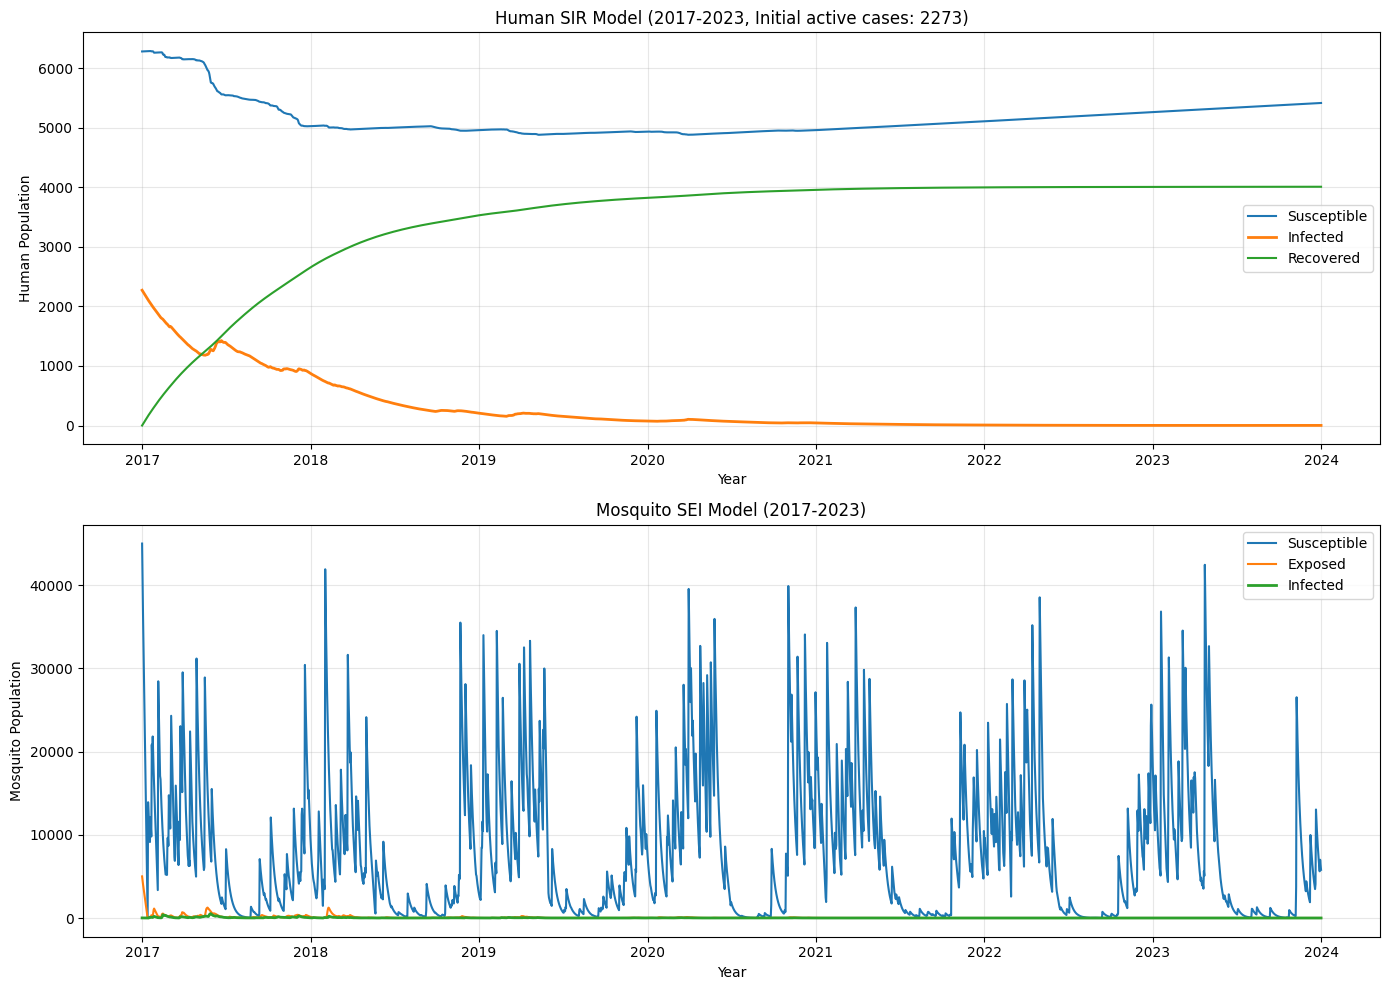

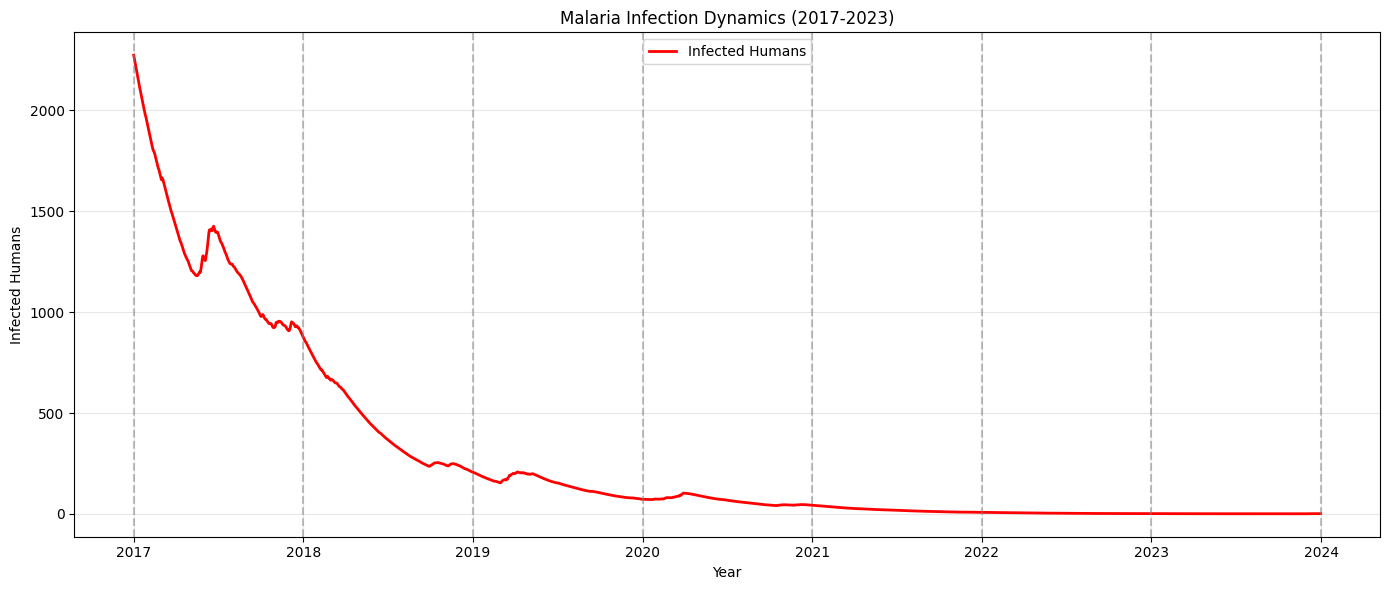

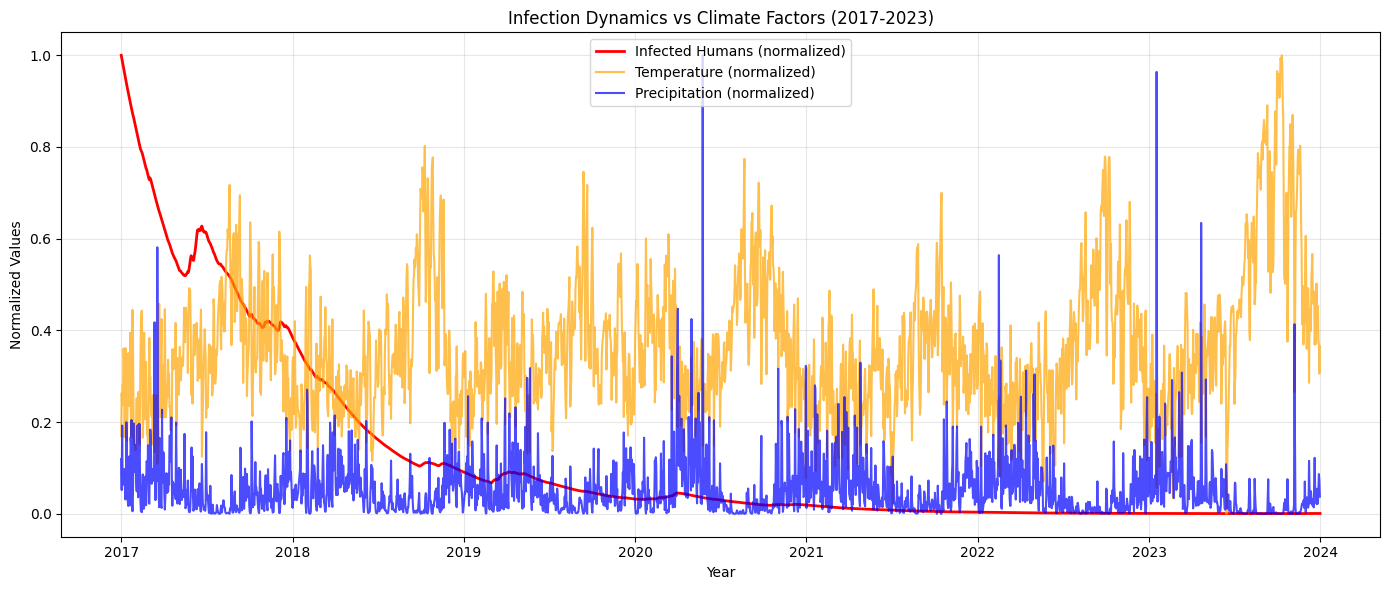

In [13]:
# Convert days to years (starting from 2017)
years = 2017 + t_eval / 365.25

# Create time array for climate data
climate_years = pd.date_range(start=start_date, end=end_date, freq='D')
climate_years = climate_years.year + (climate_years.dayofyear - 1) / 365.25

# Plot 1: Human populations (SIR)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

ax1.plot(years, S_H, label='Susceptible', linewidth=1.5)
ax1.plot(years, I_H, label='Infected', linewidth=2)
ax1.plot(years, R_H, label='Recovered', linewidth=1.5)
ax1.set_xlabel('Year')
ax1.set_ylabel('Human Population')
ax1.set_title(f'Human SIR Model (2017-2023, Initial active cases: {I_H0:.0f})')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Mosquito populations (SEI)
ax2.plot(years, S_M, label='Susceptible', linewidth=1.5)
ax2.plot(years, E_M, label='Exposed', linewidth=1.5)
ax2.plot(years, I_M, label='Infected', linewidth=2)
ax2.set_xlabel('Year')
ax2.set_ylabel('Mosquito Population')
ax2.set_title('Mosquito SEI Model (2017-2023)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot 3: Detailed infection dynamics
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(years, I_H, 'r-', linewidth=2, label='Infected Humans')
ax.set_xlabel('Year')
ax.set_ylabel('Infected Humans')
ax.set_title('Malaria Infection Dynamics (2017-2023)')
ax.legend()
ax.grid(True, alpha=0.3)

# Add vertical lines to mark years
for year in range(2017, 2025):
    ax.axvline(x=year, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Plot 4: Climate influence on infection
fig, ax = plt.subplots(figsize=(14, 6))

# Extract climate data
clim_temps = climate_api_data['temp_med'].values
clim_rains = climate_api_data['precip_med'].values

# Normalize for plotting
I_H_norm = I_H / max(I_H) if max(I_H) > 0 else I_H
temp_norm = (clim_temps - np.nanmin(clim_temps)) / (np.nanmax(clim_temps) - np.nanmin(clim_temps))
rain_norm = clim_rains / np.nanmax(clim_rains) if np.nanmax(clim_rains) > 0 else clim_rains

ax.plot(years, I_H_norm, 'r-', linewidth=2, label='Infected Humans (normalized)')
ax.plot(climate_years, temp_norm, 'orange', linewidth=1.5, alpha=0.7, label='Temperature (normalized)')
ax.plot(climate_years, rain_norm, 'blue', linewidth=1.5, alpha=0.7, label='Precipitation (normalized)')
ax.set_xlabel('Year')
ax.set_ylabel('Normalized Values')
ax.set_title('Infection Dynamics vs Climate Factors (2017-2023)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
print("\n" + "="*60)
print("SIMULATION STATISTICS (2017-2023)")
print("="*60)

# Find infection peaks
peaks, peak_props = find_peaks(I_H, distance=180)

print(f"\nNumber of infection waves detected: {len(peaks)}")
if len(peaks) > 0:
    print("\nPeak infections:")
    for i, peak_idx in enumerate(peaks):
        peak_year = years[peak_idx]
        peak_value = I_H[peak_idx]
        print(f"  Wave {i+1}: {peak_year:.2f}, Infections: {peak_value:.0f}")

# Average infection level
avg_infected = np.mean(I_H[I_H > 0]) if np.any(I_H > 0) else 0
print(f"\nAverage infected population: {avg_infected:.0f}")
print(f"Peak infected population: {I_H.max():.0f}")
print(f"Final susceptible population: {S_H[-1]:.0f}")
print(f"Final recovered population: {R_H[-1]:.0f}")
print(f"Total infected over simulation: {sum(I_H):.0f} person-days")


SIMULATION STATISTICS (2017-2023)

Number of infection waves detected: 11

Peak infections:
  Wave 1: 2017.17, Infections: 1666
  Wave 2: 2017.76, Infections: 989
  Wave 3: 2018.80, Infections: 255
  Wave 4: 2019.30, Infections: 205
  Wave 5: 2020.24, Infections: 104
  Wave 6: 2020.93, Infections: 47
  Wave 7: 2021.87, Infections: 9
  Wave 8: 2022.40, Infections: 4
  Wave 9: 2022.94, Infections: 2
  Wave 10: 2023.45, Infections: 1
  Wave 11: 2023.99, Infections: 2

Average infected population: 282
Peak infected population: 2273
Final susceptible population: 5419
Final recovered population: 4012
Total infected over simulation: 720026 person-days
